In [8]:
# Cell 1: Import Libraries & Load Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

# Load data
df = pd.read_csv('border_intrusion.csv')
features = df.columns.tolist()
X = df.values

print(f"✓ Loaded {len(df)} samples with {len(features)} features")
print(f"✓ Features: {features}")

✓ Loaded 1999 samples with 6 features
✓ Features: ['entry_angle', 'speed', 'speed_variance', 'stop_duration', 'time_of_intrusion', 'path_deviation']


✓ Data normalized


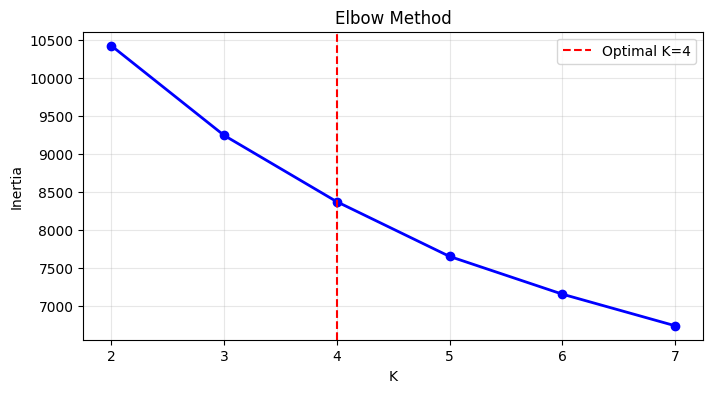

✓ Optimal K = 4


In [14]:
# Cell 2: Normalize Data
means, stds = np.mean(X, axis=0), np.std(X, axis=0)
X_norm = (X - means) / stds  # Z-Score normalization

print("✓ Data normalized")
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_norm).inertia_ for k in range(2, 8)]

plt.figure(figsize=(8, 4))
plt.plot(range(2, 8), inertias, 'bo-', linewidth=2)
plt.axvline(x=4, color='r', linestyle='--', label='Optimal K=4')
plt.xlabel('K'); plt.ylabel('Inertia'); plt.title('Elbow Method')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('elbow_library.png', dpi=100); plt.show()
print("✓ Optimal K = 4")

In [11]:
# Cell 3: Run K-Means (K=4) for All Distance Metrics
K = 4
results = {}

# Get reference labels from sklearn KMeans
sklearn_kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
true_labels = sklearn_kmeans.fit_predict(X_norm)

print("=" * 65)
print("CLUSTERING RESULTS (K=4)")
print("=" * 65)
print(f"{'Metric':<12} | {'Accuracy':>10} |")
print("-" * 65)
for metric, metric_name in zip(['euclidean', 'manhattan', 'chebyshev'], ['euclidean', 'cityblock', 'chebyshev']):
    model = KMeans(n_clusters=K, random_state=42, n_init=10, algorithm='lloyd',)
    # For non-euclidean, precompute distance matrix and assign clusters manually
    if metric == 'euclidean':
        labels = model.fit_predict(X_norm)
        centroids = model.cluster_centers_
    else:
        # Lloyd's algorithm only supports Euclidean, so we use distance matrix for assignment
        centroids = X_norm[np.random.choice(len(X_norm), K, replace=False)]
        for _ in range(100):
            dists = cdist(X_norm, centroids, metric=metric_name)
            labels = np.argmin(dists, axis=1)
            new_centroids = np.array([X_norm[labels == i].mean(axis=0) for i in range(K)])
            if np.allclose(centroids, new_centroids):
                break
            centroids = new_centroids
    # Align labels for accuracy calculation
    cm = np.zeros((K, K), dtype=int)
    for i in range(K):
        for j in range(K):
            cm[i, j] = np.sum((true_labels == i) & (labels == j))
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    aligned_labels = np.array([mapping.get(l, l) for l in labels])
    acc = round(accuracy_score(true_labels, aligned_labels) * 100, 2)
    results[metric] = {'labels': labels, 'centroids': centroids.tolist(), 'accuracy': acc}
    print(f"{metric.upper():<12} | {acc:>9.2f}% |")
print("✓ Clustering completed for all metrics")

CLUSTERING RESULTS (K=4)
Metric       |   Accuracy |
-----------------------------------------------------------------
EUCLIDEAN    |    100.00% |
MANHATTAN    |     63.33% |
CHEBYSHEV    |     55.38% |
✓ Clustering completed for all metrics


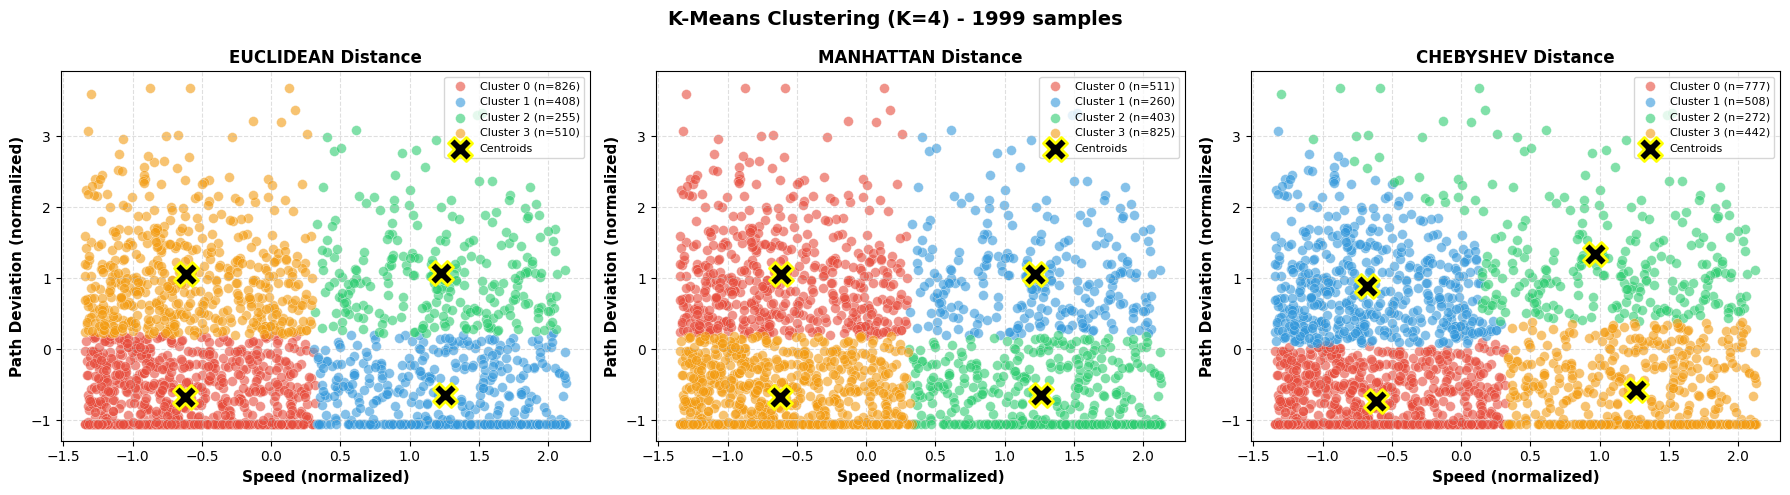

✓ Features used: ['speed', 'path_deviation']
✓ Total samples: 1999
✓ Saved: clustering_2d_map.png


In [12]:
# Cell 4: 2D Clustering using 2 Key Features (speed & path_deviation)

key_features = ['speed', 'path_deviation']
feat_idx = [features.index(f) for f in key_features]
X_2d = X_norm[:, feat_idx]

# Re-run K-Means on 2D data for all metrics
results_2d = {}
for metric, metric_name in zip(['euclidean', 'manhattan', 'chebyshev'], ['euclidean', 'cityblock', 'chebyshev']):
    model_2d = KMeans(n_clusters=K, random_state=42, n_init=10, algorithm='lloyd')
    if metric == 'euclidean':
        labels_2d = model_2d.fit_predict(X_2d)
        centroids_2d = model_2d.cluster_centers_
    else:
        centroids_2d = X_2d[np.random.choice(len(X_2d), K, replace=False)]
        for _ in range(100):
            dists = cdist(X_2d, centroids_2d, metric=metric_name)
            labels_2d = np.argmin(dists, axis=1)
            new_centroids_2d = np.array([X_2d[labels_2d == i].mean(axis=0) for i in range(K)])
            if np.allclose(centroids_2d, new_centroids_2d):
                break
            centroids_2d = new_centroids_2d
    results_2d[metric] = {'labels': labels_2d, 'centroids': centroids_2d}

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for idx, (metric, data) in enumerate(results_2d.items()):
    ax = axes[idx]
    labels = data['labels']
    centroids = data['centroids']
    for cluster_id in range(K):
        mask = (labels == cluster_id)
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], 
                   c=colors[cluster_id], marker='o',
                   label=f'Cluster {cluster_id} (n={np.sum(mask)})',
                   alpha=0.6, s=50, edgecolors='white', linewidth=0.3)
    ax.scatter(centroids[:, 0], centroids[:, 1], 
               c='black', marker='X', s=300, edgecolors='yellow', linewidth=2,
               label='Centroids', zorder=10)
    ax.set_xlabel('Speed (normalized)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Path Deviation (normalized)', fontsize=11, fontweight='bold')
    ax.set_title(f'{metric.upper()} Distance', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.4, linestyle='--')

plt.suptitle(f'K-Means Clustering (K={K}) - {len(X_2d)} samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('clustering_2d_map.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Features used: {key_features}")
print(f"✓ Total samples: {len(X_2d)}")
print(f"✓ Saved: clustering_2d_map.png")

In [13]:
# Cell 5: Save Results for Flask Web App
output = {
    'scaler_mean': means.tolist(), 
    'scaler_scale': stds.tolist(), 
    'k': K, 
    'features': features
}
for metric, data in results.items():
    output[metric] = {
        'centroids': data['centroids'], 
        'accuracy': data['accuracy']
    }

with open('model_results_library.json', 'w') as f:
    json.dump(output, f, indent=2)

print("✓ Saved: model_results_library.json")
print("\nAccuracy Scores:")
for metric, data in results.items():
    print(f"  {metric.upper()}: {data['accuracy']}%")

✓ Saved: model_results_library.json

Accuracy Scores:
  EUCLIDEAN: 100.0%
  MANHATTAN: 63.33%
  CHEBYSHEV: 55.38%
